# TensorFlow Guide: From Basics to Neural Networks

This notebook is a comprehensive, self-contained guide to TensorFlow. It explains **every concept from scratch**, walks through each building block, and finishes with a fully explained neural network trained on real image data.

---

## Table of Contents
1. [What is TensorFlow?](#1)
2. [Tensors — The Core Data Type](#2)
3. [Variables vs Constants](#3)
4. [Automatic Differentiation with GradientTape](#4)
5. [Key TensorFlow Operations](#5)
6. [Building a Neural Network Step by Step (Low-Level API)](#6)
   - 6.1 Dataset & Preprocessing
   - 6.2 Parameter Initialization
   - 6.3 Forward Propagation
   - 6.4 Loss Function
   - 6.5 Training Loop
   - 6.6 Evaluation
7. [Building the Same Network with Keras (High-Level API)](#7)
8. [Saving and Loading a Model](#8)
9. [Common Mistakes and Tips](#9)
10. [Keras Model Types and Layer Reference](#10)

---
<a name='1'></a>
## 1. What is TensorFlow?

**TensorFlow** is an open-source numerical computation library developed by Google Brain. It is designed for:
- Defining mathematical computations as **dataflow graphs**
- Automatically computing **gradients** (derivatives) of those computations
- Running computations efficiently on **CPU, GPU, or TPU**

### TF 1.x vs TF 2.x — What Changed?

| Feature | TF 1.x | TF 2.x |
|---|---|---|
| Execution | Static graph (build first, run later) | **Eager execution** (runs immediately, like NumPy) |
| Session | Required `tf.Session()` to run | No sessions needed |
| Debugging | Hard — graph runs all at once | Easy — step through code normally |
| Keras | Separate library | **Built-in**, recommended high-level API |

**TF 2.x** is what we use today. It feels much more like NumPy — operations execute immediately and you can print/inspect values at any line.

### Relationship Between TensorFlow and Keras

```
┌──────────────────────────────────┐
│           Your Code              │
├──────────────────────────────────┤
│  Keras  (tf.keras)               │  ← High-level: Sequential, layers, .fit()
├──────────────────────────────────┤
│  TensorFlow Core  (tf.*)         │  ← Low-level: tensors, ops, GradientTape
├──────────────────────────────────┤
│  Hardware  (CPU / GPU / TPU)     │
└──────────────────────────────────┘
```

You can use **either level** — or mix them. In this guide you'll learn both.

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("Eager execution enabled:", tf.executing_eagerly())

TensorFlow version: 2.21.0
Eager execution enabled: True


---
<a name='2'></a>
## 2. Tensors: The Core Data Type

A **tensor** is the fundamental data structure in TensorFlow. Think of it as a multidimensional array — exactly like a NumPy array, but with extra superpowers:
- It knows how to run on GPU
- It can track gradients

### Rank (number of dimensions)

| Rank | Name | Example shape | Analogy |
|------|------|---------------|---------|
| 0 | Scalar | `()` | A single number: `5.0` |
| 1 | Vector | `(n,)` | A list of numbers |
| 2 | Matrix | `(m, n)` | A table / 2D array |
| 3 | 3-D Tensor | `(samples, timesteps, features)`; `(batch, height, width)` | Time-series data — e.g. 1 000 sensor recordings, each with 50 timesteps and 3 measurements (temp, pressure, humidity) per step; A batch of grayscale images |
| 4 | 4-D Tensor | `(entities, timesteps, features, vars)`;  `(batch, height, width, channels)` | **Panel (multi-entity) time-series** — e.g. 100 stocks × 252 trading days × 10 financial features; A batch of color images |

### Creating Tensors

In [2]:
# Rank-0: scalar
scalar = tf.constant(7.0)
print("Scalar:", scalar)
print("  shape:", scalar.shape, "  rank:", scalar.ndim)

# Rank-1: vector
vector = tf.constant([1.0, 2.0, 3.0])
print("\nVector:", vector)
print("  shape:", vector.shape)

# Rank-2: matrix
matrix = tf.constant([[1, 2, 3],
                       [4, 5, 6]], dtype=tf.float32)
print("\nMatrix:\n", matrix)
print("  shape:", matrix.shape)

# Rank-3: time-series data
# Shape: (samples, timesteps, features)
# Example: 4 sensors, each measured over 10 timesteps, with 3 values each
#          (temperature, pressure, humidity)
time_series = tf.random.normal(shape=(4, 10, 3))
print("\nTime-series tensor shape:", time_series.shape,
      "  → (samples, timesteps, features)")
print("  First sensor, first timestep, all 3 features:",
      time_series[0, 0, :].numpy().round(3))

# Rank-4: batch of color images (2 images of 4×4 pixels, 3 channels)
images = tf.zeros(shape=(2, 4, 4, 3))
print("\nImage batch shape:", images.shape,
      "  → (batch, height, width, channels)")

Scalar: tf.Tensor(7.0, shape=(), dtype=float32)
  shape: ()   rank: 0

Vector: tf.Tensor([1. 2. 3.], shape=(3,), dtype=float32)
  shape: (3,)

Matrix:
 tf.Tensor(
[[1. 2. 3.]
 [4. 5. 6.]], shape=(2, 3), dtype=float32)
  shape: (2, 3)

Time-series tensor shape: (4, 10, 3)   → (samples, timesteps, features)
  First sensor, first timestep, all 3 features: [-0.667 -1.071 -1.041]

Image batch shape: (2, 4, 4, 3)   → (batch, height, width, channels)


In [3]:
# Useful tensor factory functions
print(tf.zeros((3, 3)))          # all zeros
print(tf.ones((2, 4)))           # all ones
print(tf.eye(3))                 # 3×3 identity matrix
print(tf.random.normal((2, 3)))  # standard normal values
print(tf.range(0, 10, 2))        # like Python range: 0, 2, 4, 6, 8

tf.Tensor(
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]], shape=(3, 3), dtype=float32)
tf.Tensor(
[[1. 1. 1. 1.]
 [1. 1. 1. 1.]], shape=(2, 4), dtype=float32)
tf.Tensor(
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]], shape=(3, 3), dtype=float32)
tf.Tensor(
[[-1.6404343  -0.06723811  1.6372875 ]
 [ 0.33964047  0.7560145   0.11204286]], shape=(2, 3), dtype=float32)
tf.Tensor([0 2 4 6 8], shape=(5,), dtype=int32)


In [4]:
# Tensors and NumPy arrays interoperate seamlessly
np_array = np.array([1.0, 2.0, 3.0])
tf_tensor = tf.constant(np_array)          # NumPy → TF
back_to_numpy = tf_tensor.numpy()          # TF → NumPy

print("TF tensor:", tf_tensor)
print("Back to NumPy:", back_to_numpy)
print("dtype:", tf_tensor.dtype)

TF tensor: tf.Tensor([1. 2. 3.], shape=(3,), dtype=float64)
Back to NumPy: [1. 2. 3.]
dtype: <dtype: 'float64'>


### Important: Constant Tensors are Immutable

`tf.constant` creates a **read-only** tensor — you cannot change its values after creation. To store a mutable value (e.g. a neural network weight that gets updated during training), you need `tf.Variable` — covered next.

---
<a name='3'></a>
## 3. Variables vs Constants

| | `tf.constant` | `tf.Variable` |
|---|---|---|
| Mutable? | No | Yes |
| Used for | Data, hyperparams | **Weights, biases** |
| Gradient tracked? | Yes (during tape) | **Yes, always** |
| Can reassign value? | No | Yes, via `.assign()` |

**Rule of thumb:** if it changes during training → `tf.Variable`. Everything else → `tf.constant`.

In [5]:
# tf.Variable — mutable, represents a model parameter
W = tf.Variable([[0.5, -0.3],
                 [0.1,  0.8]], dtype=tf.float32, name="weights")
b = tf.Variable([0.0, 0.0], dtype=tf.float32, name="bias")

print("W initial value:\n", W.numpy())

# Modify in-place with .assign() or .assign_add()
W.assign_add([[0.1, 0.1], [0.1, 0.1]])
print("\nW after assign_add:\n", W.numpy())

# Directly replace
b.assign([1.0, 2.0])
print("\nb after assign:", b.numpy())

W initial value:
 [[ 0.5 -0.3]
 [ 0.1  0.8]]

W after assign_add:
 [[ 0.6        -0.20000002]
 [ 0.2         0.90000004]]

b after assign: [1. 2.]


In [6]:
# tf.constant — immutable
x = tf.constant([1.0, 2.0, 3.0])

try:
    x.assign([4.0, 5.0, 6.0])   # This will raise an error
except AttributeError as e:
    print("Cannot assign to a constant:", e)

Cannot assign to a constant: 'tensorflow.python.framework.ops.EagerTensor' object has no attribute 'assign'


---
<a name='4'></a>
## 4. Automatic Differentiation with `GradientTape`

This is the **heart of TensorFlow**. To train a neural network you need gradients of the loss with respect to every parameter (so you can update the parameters via gradient descent). Computing those gradients by hand is impractical — `GradientTape` does it automatically.

### How it works

```
  with tf.GradientTape() as tape:
      y = f(x)        ← forward pass is RECORDED
  
  dy_dx = tape.gradient(y, x)   ← backward pass is COMPUTED
```

Inside the `with` block TensorFlow records every operation. When you call `.gradient()` it "plays back" those recorded operations in reverse, applying the chain rule automatically — this is **backpropagation**.

### Simple Example: derivative of a polynomial

In [7]:
# Compute d/dx [ x^2 + 3x ] at x = 4
# Analytically: 2x + 3 = 11

x = tf.Variable(4.0)

with tf.GradientTape() as tape:
    y = x**2 + 3*x          # y = x² + 3x

dy_dx = tape.gradient(y, x)
print(f"y  = {y.numpy():.1f}")
print(f"dy/dx = {dy_dx.numpy():.1f}  (expected: 2*4 + 3 = 11)")

y  = 28.0
dy/dx = 11.0  (expected: 2*4 + 3 = 11)


In [8]:
# Gradient with respect to MULTIPLE variables at once
# — exactly what happens during neural network training

W = tf.Variable(2.0)   # simulated weight
b = tf.Variable(1.0)   # simulated bias
x_input = tf.constant(3.0)

with tf.GradientTape() as tape:
    # simple linear model: y_pred = W*x + b
    y_pred = W * x_input + b
    y_true = tf.constant(10.0)
    # mean squared error loss
    loss = (y_pred - y_true) ** 2

# Compute gradients of loss with respect to [W, b]
gradients = tape.gradient(loss, [W, b])
dL_dW, dL_db = gradients

print(f"y_pred = {y_pred.numpy()}, loss = {loss.numpy():.2f}")
print(f"dL/dW  = {dL_dW.numpy():.2f}   (how much loss changes if W increases)")
print(f"dL/db  = {dL_db.numpy():.2f}   (how much loss changes if b increases)")

y_pred = 7.0, loss = 9.00
dL/dW  = -18.00   (how much loss changes if W increases)
dL/db  = -6.00   (how much loss changes if b increases)


Learned W = 2.859  (true value: 3.0)
Learned b = 0.028    (true value: 0.0)


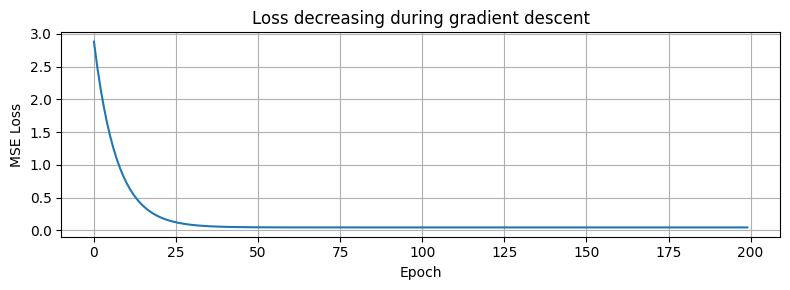

In [9]:
# Full gradient descent training loop for a simple linear model
# Goal: learn y = 3x from noisy data

np.random.seed(0)
X_data = np.linspace(-1, 1, 50).astype(np.float32).reshape(-1, 1)
Y_data = 3.0 * X_data + np.random.randn(50, 1).astype(np.float32) * 0.2

W = tf.Variable([[0.0]])   # start with wrong weight
b = tf.Variable([0.0])

learning_rate = 0.1
losses = []

for epoch in range(200):
    with tf.GradientTape() as tape:
        y_pred = X_data @ W + b                    # matrix multiply
        loss = tf.reduce_mean((y_pred - Y_data)**2) # MSE
    
    grads = tape.gradient(loss, [W, b])
    
    # Gradient descent update: param = param - lr * gradient
    W.assign_sub(learning_rate * grads[0])
    b.assign_sub(learning_rate * grads[1])
    
    losses.append(loss.numpy())

print(f"Learned W = {W.numpy()[0,0]:.3f}  (true value: 3.0)")
print(f"Learned b = {b.numpy()[0]:.3f}    (true value: 0.0)")

plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss decreasing during gradient descent")
plt.grid(True)
plt.tight_layout()
plt.show()

**Key takeaway:** `GradientTape` lets you write any forward pass you want, and automatically computes the gradients needed to update the parameters. You don't need to derive anything by hand.

---
<a name='5'></a>
## 5. Key TensorFlow Operations

Before building a neural network, let's go through the operations you'll use most often.

In [10]:
# ── Math operations ─────────────────────────────────────────────
a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
b = tf.constant([[5.0, 6.0], [7.0, 8.0]])

print("Element-wise add:\n",  a + b)
print("Element-wise mul:\n",  a * b)
print("Matrix multiply (a @ b):\n", a @ b)          # same as tf.matmul(a, b)
print("Transpose:\n",         tf.transpose(a))

Element-wise add:
 tf.Tensor(
[[ 6.  8.]
 [10. 12.]], shape=(2, 2), dtype=float32)
Element-wise mul:
 tf.Tensor(
[[ 5. 12.]
 [21. 32.]], shape=(2, 2), dtype=float32)
Matrix multiply (a @ b):
 tf.Tensor(
[[19. 22.]
 [43. 50.]], shape=(2, 2), dtype=float32)
Transpose:
 tf.Tensor(
[[1. 3.]
 [2. 4.]], shape=(2, 2), dtype=float32)


In [11]:
# ── Reduction operations ─────────────────────────────────────────
x = tf.constant([[1.0, 2.0, 3.0],
                 [4.0, 5.0, 6.0]])

print("Sum of all elements: ",  tf.reduce_sum(x).numpy())
print("Mean of all elements:",  tf.reduce_mean(x).numpy())
print("Max of all elements: ",  tf.reduce_max(x).numpy())

# axis=0 collapses rows (operate down each column)
# axis=1 collapses columns (operate across each row)
print("\nSum along axis=0 (per column):", tf.reduce_sum(x, axis=0).numpy())
print("Sum along axis=1 (per row):   ", tf.reduce_sum(x, axis=1).numpy())

Sum of all elements:  21.0
Mean of all elements: 3.5
Max of all elements:  6.0

Sum along axis=0 (per column): [5. 7. 9.]
Sum along axis=1 (per row):    [ 6. 15.]


In [12]:
# ── Shape manipulation ───────────────────────────────────────────
x = tf.range(24, dtype=tf.float32)
print("Original shape:", x.shape)         # (24,)

x_2d = tf.reshape(x, (4, 6))
print("Reshaped to (4,6):\n", x_2d.numpy())

x_3d = tf.reshape(x, (2, 3, 4))
print("\nReshaped to (2,3,4) — shape:", x_3d.shape)

# Add/remove a size-1 dimension (important for batching!)
v = tf.constant([1.0, 2.0, 3.0])          # shape (3,)
v_col = tf.expand_dims(v, axis=1)         # shape (3, 1) — column vector
print("\nexpand_dims:", v_col.shape)

Original shape: (24,)
Reshaped to (4,6):
 [[ 0.  1.  2.  3.  4.  5.]
 [ 6.  7.  8.  9. 10. 11.]
 [12. 13. 14. 15. 16. 17.]
 [18. 19. 20. 21. 22. 23.]]

Reshaped to (2,3,4) — shape: (2, 3, 4)

expand_dims: (3, 1)


In [13]:
# ── Activation functions used in neural networks ─────────────────
z = tf.constant([-3.0, -1.0, 0.0, 1.0, 3.0])

print("Input z:        ", z.numpy())
print("ReLU  max(0,z): ", tf.nn.relu(z).numpy())
print("Sigmoid 1/(1+e^-z):", tf.nn.sigmoid(z).numpy().round(3))
print("Tanh:           ", tf.nn.tanh(z).numpy().round(3))

# Softmax: converts raw scores (logits) into probabilities that sum to 1
logits = tf.constant([[2.0, 1.0, 0.1]])    # 3-class scores
probs  = tf.nn.softmax(logits)
print("\nSoftmax of", logits.numpy(), "->", probs.numpy().round(3))
print("Sum of probabilities:", tf.reduce_sum(probs).numpy())

Input z:         [-3. -1.  0.  1.  3.]
ReLU  max(0,z):  [0. 0. 0. 1. 3.]
Sigmoid 1/(1+e^-z): [0.047 0.269 0.5   0.731 0.953]
Tanh:            [-0.995 -0.762  0.     0.762  0.995]

Softmax of [[2.  1.  0.1]] -> [[0.659 0.242 0.099]]
Sum of probabilities: 0.99999994


In [14]:
# ── One-hot encoding ─────────────────────────────────────────────
# Convert integer class labels to a binary vector
# e.g. class 2 out of 5 → [0, 0, 1, 0, 0]

labels = tf.constant([0, 2, 4, 1, 3])     # 5 samples, classes 0–4
one_hot = tf.one_hot(labels, depth=5)

print("Integer labels:", labels.numpy())
print("One-hot encoded:\n", one_hot.numpy())

Integer labels: [0 2 4 1 3]
One-hot encoded:
 [[1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0.]]


---
<a name='6'></a>
## 6. Building a Neural Network Step by Step (Low-Level API)

We will build a **3-layer neural network** from scratch using only `tf.Variable`, `tf.matmul`, and `GradientTape`. This mirrors exactly what Keras does under the hood, but writing it manually means you understand every moving part.

### The Task
Classify **handwritten digits (MNIST)** — 10 classes (0–9), 28×28 grayscale images.

### Network Architecture

```
Input           Hidden layer 1     Hidden layer 2     Output
(784,)   →  W1   (256,)   →  W2    (128,)   →  W3   (10,)
          + b1  [ReLU]    + b2   [ReLU]    + b3  [Softmax]
```

- Input: 784 features (28×28 pixels flattened)
- Hidden 1: 256 neurons, ReLU activation
- Hidden 2: 128 neurons, ReLU activation  
- Output: 10 neurons (one per digit class), Softmax

### Why ReLU?
ReLU (Rectified Linear Unit) = `max(0, z)`. It is the default activation for hidden layers because:
- It is simple and fast to compute
- Its gradient is either 0 or 1, which avoids the **vanishing gradient** problem that sigmoid/tanh suffer from in deep networks

### Why Softmax at the output?
For multi-class classification we want the output to be a probability distribution (values between 0 and 1, summing to 1). Softmax does exactly this.

### 6.1. Dataset and Preprocessing

In [15]:
# Load MNIST from keras datasets (built-in, no download needed)
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = tf.keras.datasets.mnist.load_data()

print("Training images shape:", X_train_raw.shape)   # (60000, 28, 28)
print("Training labels shape:", y_train_raw.shape)   # (60000,)
print("Pixel value range: [{}, {}]".format(X_train_raw.min(), X_train_raw.max()))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Pixel value range: [0, 255]


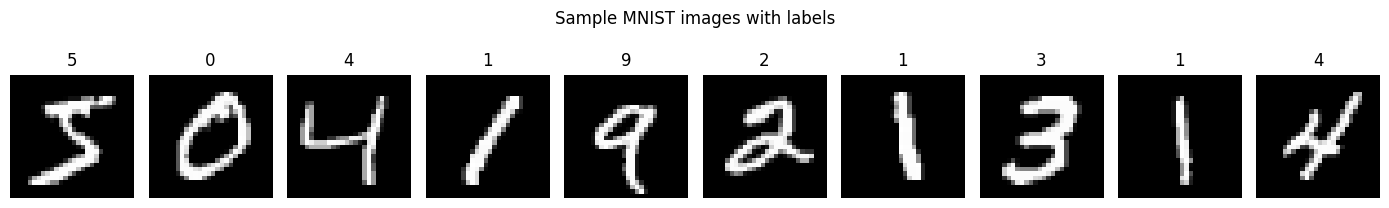

In [16]:
# Visualize a few examples
fig, axes = plt.subplots(1, 10, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_train_raw[i], cmap='gray')
    ax.set_title(str(y_train_raw[i]))
    ax.axis('off')
plt.suptitle("Sample MNIST images with labels", y=1.05)
plt.tight_layout()
plt.show()

In [17]:
# ── Preprocessing steps ──────────────────────────────────────────

# Step 1: Flatten 28×28 → 784
# The network expects a 1D vector per sample, not a 2D image.
X_train = X_train_raw.reshape(-1, 784).astype(np.float32)
X_test  = X_test_raw.reshape(-1, 784).astype(np.float32)

# Step 2: Normalize pixel values from [0, 255] to [0, 1]
# This ensures gradients are on a similar scale for all inputs,
# which makes training faster and more stable.
X_train /= 255.0
X_test  /= 255.0

# Step 3: One-hot encode labels
# Instead of label=3, we want [0,0,0,1,0,0,0,0,0,0]
# because our network outputs 10 probabilities.
Y_train = tf.one_hot(y_train_raw, depth=10)   # shape (60000, 10)
Y_test  = tf.one_hot(y_test_raw,  depth=10)   # shape (10000, 10)

print("X_train:", X_train.shape, "  range:", X_train.min(), "-", X_train.max())
print("Y_train:", Y_train.shape)

X_train: (60000, 784)   range: 0.0 - 1.0
Y_train: (60000, 10)


In [18]:
# Build a mini-batch dataset pipeline using tf.data
# Mini-batching = train on a small chunk of data per step instead of all at once.
# Advantages: fits in memory, provides noisy gradients that help escape local minima.

BATCH_SIZE = 256

train_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train, Y_train))   # pair each input with its label
    .shuffle(buffer_size=10000)               # shuffle order every epoch
    .batch(BATCH_SIZE)                        # group into batches of 256
    .prefetch(tf.data.AUTOTUNE)               # load next batch while GPU runs current
)

test_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_test, Y_test))
    .batch(BATCH_SIZE)
)

print("Number of training batches per epoch:",
      len(list(train_ds)))   # 60000 / 256 ≈ 235 batches

Number of training batches per epoch: 235


### 6.2. Parameter Initialization

Every layer has:
- A **weight matrix** `W` of shape `(input_size, output_size)`
- A **bias vector** `b` of shape `(1, output_size)` (broadcast over the batch)

**Why random initialization?** If all weights start at zero, all neurons compute the same thing and gradients are identical — the network never learns different features. Small random values break this symmetry.

**Xavier / Glorot initialization** (used below) scales the random values by `sqrt(2 / fan_in)` to keep the variance of activations stable across layers.

In [19]:
def initialize_parameters(layer_dims):
    """
    Initialize weights and biases for a fully-connected network.

    Args:
        layer_dims: list of layer sizes, e.g. [784, 256, 128, 10]
                    layer_dims[0] = input features
                    layer_dims[-1] = number of output classes

    Returns:
        params: dict with keys W1, b1, W2, b2, ...
    """
    params = {}
    initializer = tf.initializers.GlorotUniform(seed=42)  # Xavier init

    for l in range(1, len(layer_dims)):
        params[f"W{l}"] = tf.Variable(
            initializer(shape=(layer_dims[l-1], layer_dims[l])),
            dtype=tf.float32,
            name=f"W{l}"
        )
        params[f"b{l}"] = tf.Variable(
            tf.zeros((1, layer_dims[l])),
            dtype=tf.float32,
            name=f"b{l}"
        )

    return params


# 784 inputs → 256 hidden → 128 hidden → 10 outputs
params = initialize_parameters([784, 256, 128, 10])

for name, var in params.items():
    print(f"{name}: shape={var.shape}")

W1: shape=(784, 256)
b1: shape=(1, 256)
W2: shape=(256, 128)
b2: shape=(1, 128)
W3: shape=(128, 10)
b3: shape=(1, 10)


### 6.3. Forward Propagation

For each layer `l`, the computation is:

$$Z^{[l]} = A^{[l-1]} \cdot W^{[l]} + b^{[l]}$$
$$A^{[l]} = g^{[l]}(Z^{[l]})$$

Where:
- $A^{[0]} = X$ (the input batch)
- $g^{[l]}$ is the activation function (ReLU for hidden layers, Softmax for output)
- The `@` operator is matrix multiplication

For a batch of `m` samples with `n` features and a layer of `k` neurons:
- `A` has shape `(m, n)` — each row is one sample
- `W` has shape `(n, k)` — each column is one neuron's weights
- `A @ W` has shape `(m, k)` — each row is one sample's activations

In [20]:
def forward_propagation(X, params):
    """
    Run forward propagation through the network.

    Args:
        X:      input batch, shape (batch_size, 784)
        params: dict of Variables {W1, b1, W2, b2, W3, b3}

    Returns:
        A3: output probabilities, shape (batch_size, 10)
    """
    # ── Layer 1 ────────────────────────────────────────────
    # Linear step: each pixel gets a weight, results are summed + bias
    Z1 = X @ params["W1"] + params["b1"]   # (batch, 784) @ (784, 256) → (batch, 256)
    # Activation: ReLU zeroes out negative values
    A1 = tf.nn.relu(Z1)                    # (batch, 256)

    # ── Layer 2 ────────────────────────────────────────────
    Z2 = A1 @ params["W2"] + params["b2"]  # (batch, 256) @ (256, 128) → (batch, 128)
    A2 = tf.nn.relu(Z2)                    # (batch, 128)

    # ── Output layer ───────────────────────────────────────
    Z3 = A2 @ params["W3"] + params["b3"]  # (batch, 128) @ (128, 10)  → (batch, 10)
    # Softmax: convert raw scores to probabilities summing to 1
    A3 = tf.nn.softmax(Z3)                 # (batch, 10)

    return A3


# Test with a single batch
X_sample = X_train[:5]
output = forward_propagation(X_sample, params)
print("Output shape:", output.shape)
print("Probabilities for first sample (should sum to 1):\n", output[0].numpy().round(3))
print("Sum:", tf.reduce_sum(output[0]).numpy())

Output shape: (5, 10)
Probabilities for first sample (should sum to 1):
 [0.164 0.106 0.088 0.095 0.059 0.091 0.12  0.085 0.133 0.06 ]
Sum: 1.0


### 6.4. Loss Function (Cross-Entropy)

For classification we use **categorical cross-entropy**:

$$\mathcal{L} = -\frac{1}{m} \sum_{i=1}^{m} \sum_{j=1}^{C} y_{ij} \log(\hat{y}_{ij})$$

- $y_{ij}$ = 1 if sample $i$ belongs to class $j$ (from one-hot label), else 0
- $\hat{y}_{ij}$ = predicted probability that sample $i$ belongs to class $j$ (from softmax)

**Intuition:** If the true label is class 2 and the model predicts probability 0.9 for class 2, the loss is $-\log(0.9) ≈ 0.1$ (small — good prediction). If it predicts 0.01 for class 2, loss is $-\log(0.01) ≈ 4.6$ (large — bad prediction).

In practice we use `tf.keras.losses.CategoricalCrossentropy` which is numerically stable.

In [21]:
loss_fn = tf.keras.losses.CategoricalCrossentropy()

# Demonstrate what cross-entropy measures
y_true = tf.constant([[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]], dtype=tf.float32)  # true class = 2

# Good prediction: high probability for class 2
y_good = tf.constant([[0.01, 0.01, 0.90, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.02]])
# Bad prediction: spreads probability evenly
y_bad  = tf.constant([[0.1,  0.1,  0.01, 0.1,  0.1,  0.1,  0.1,  0.1,  0.1,  0.09]])

print(f"Cross-entropy (good prediction): {loss_fn(y_true, y_good).numpy():.4f}")
print(f"Cross-entropy (bad  prediction): {loss_fn(y_true, y_bad).numpy():.4f}")

Cross-entropy (good prediction): 0.1054
Cross-entropy (bad  prediction): 4.4998


### 6.5. Training Loop

The training loop repeats for `N` epochs. Each epoch:
1. Iterate over mini-batches
2. Run forward propagation inside a `GradientTape`
3. Compute the loss
4. Use the tape to compute gradients of the loss with respect to every parameter
5. Update parameters with the optimizer

We use **Adam** optimizer instead of plain gradient descent. Adam:
- Adapts the learning rate for each parameter individually
- Uses momentum (history of past gradients) to smooth updates
- In practice converges much faster than plain gradient descent

In [23]:
# Re-initialize fresh parameters
params = initialize_parameters([784, 256, 128, 10])
trainable_vars = list(params.values())   # flat list for the optimizer

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
loss_fn   = tf.keras.losses.CategoricalCrossentropy()

# Metrics to track progress
train_loss_metric = tf.keras.metrics.Mean(name='train_loss')
train_acc_metric  = tf.keras.metrics.CategoricalAccuracy(name='train_acc')

EPOCHS = 10
history = {'loss': [], 'accuracy': []}

for epoch in range(EPOCHS):
    train_loss_metric.reset_state()
    train_acc_metric.reset_state()

    for X_batch, Y_batch in train_ds:
        with tf.GradientTape() as tape:
            # Forward pass
            Y_pred = forward_propagation(X_batch, params)
            # Compute loss for this batch
            loss   = loss_fn(Y_batch, Y_pred)

        # Backpropagation: compute gradients
        grads = tape.gradient(loss, trainable_vars)

        # Update parameters
        # optimizer.apply_gradients takes (gradient, variable) pairs
        optimizer.apply_gradients(zip(grads, trainable_vars))

        train_loss_metric.update_state(loss)
        train_acc_metric.update_state(Y_batch, Y_pred)

    epoch_loss = train_loss_metric.result().numpy()
    epoch_acc  = train_acc_metric.result().numpy()
    history['loss'].append(epoch_loss)
    history['accuracy'].append(epoch_acc)

    print(f"Epoch {epoch+1:2d}/{EPOCHS}  "
          f"loss: {epoch_loss:.4f}  "
          f"accuracy: {epoch_acc:.4f}")

Epoch  1/10  loss: 0.3495  accuracy: 0.9020
Epoch  2/10  loss: 0.1357  accuracy: 0.9602
Epoch  3/10  loss: 0.0872  accuracy: 0.9740
Epoch  4/10  loss: 0.0637  accuracy: 0.9811
Epoch  5/10  loss: 0.0484  accuracy: 0.9856
Epoch  6/10  loss: 0.0368  accuracy: 0.9890
Epoch  7/10  loss: 0.0275  accuracy: 0.9918
Epoch  8/10  loss: 0.0213  accuracy: 0.9939
Epoch  9/10  loss: 0.0173  accuracy: 0.9953
Epoch 10/10  loss: 0.0130  accuracy: 0.9966


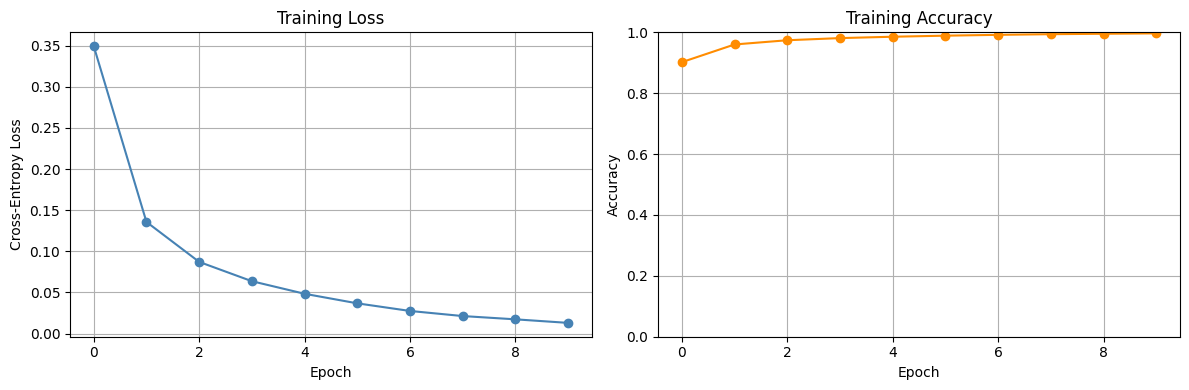

In [24]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['loss'], marker='o', color='steelblue')
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].grid(True)

axes[1].plot(history['accuracy'], marker='o', color='darkorange')
axes[1].set_title("Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 6.6. Evaluation on the Test Set

In [25]:
# Run inference on the test set (no gradient tape needed here)
correct = 0
total   = 0

for X_batch, Y_batch in test_ds:
    Y_pred  = forward_propagation(X_batch, params)
    # argmax gives the predicted class index
    pred_labels = tf.argmax(Y_pred, axis=1)
    true_labels = tf.argmax(Y_batch, axis=1)
    correct += tf.reduce_sum(tf.cast(pred_labels == true_labels, tf.int32)).numpy()
    total   += X_batch.shape[0]

test_accuracy = correct / total
print(f"Test accuracy: {test_accuracy:.4f}  ({correct}/{total} correct)")

Test accuracy: 0.9790  (9790/10000 correct)


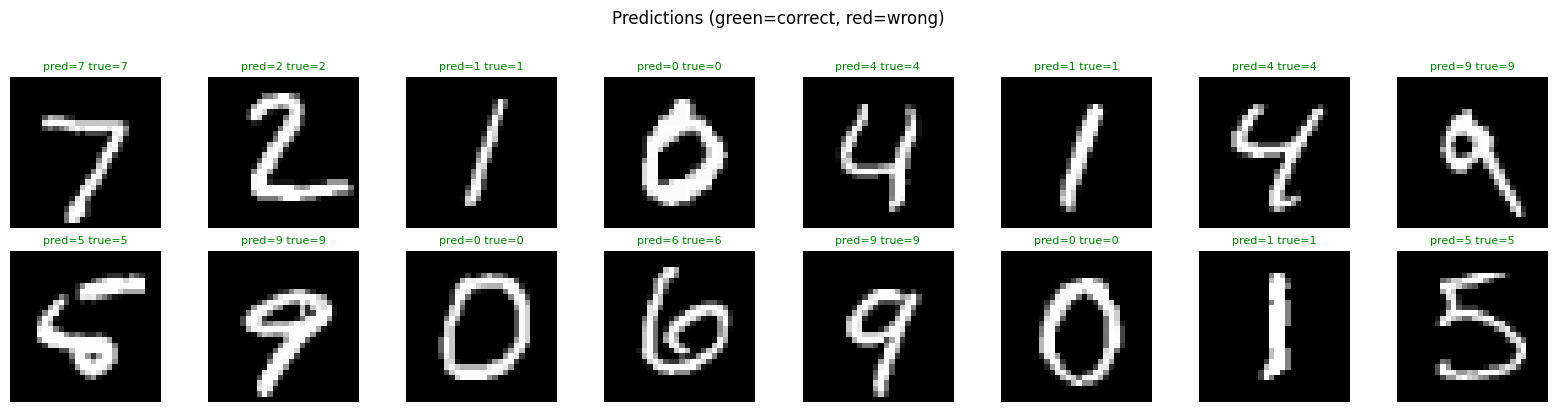

In [27]:
# Visualize predictions vs true labels
X_sample = X_test[:16]
Y_probs  = forward_propagation(X_sample, params)
preds    = tf.argmax(Y_probs, axis=1).numpy()
truths   = y_test_raw[:16]

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_sample[i].reshape(28, 28), cmap='gray')
    color = 'green' if preds[i] == truths[i] else 'red'
    ax.set_title(f"pred={preds[i]} true={truths[i]}", color=color, fontsize=8)
    ax.axis('off')
plt.suptitle("Predictions (green=correct, red=wrong)", y=1.02)
plt.tight_layout()
plt.show()

---
<a name='7'></a>
## 7. Building the Same Network with Keras (High-Level API)

The manual approach above is great for learning — you see every detail. In practice, the **Keras** API (built into TensorFlow as `tf.keras`) lets you build the exact same network in far fewer lines, while handling all the bookkeeping for you.

### Keras Sequential Model

A `Sequential` model is a linear stack of layers. You add them one by one with `.add()` or pass them as a list. Keras automatically:
- Infers shapes between layers
- Creates the `W` and `b` variables
- Manages the training loop via `.fit()`

In [28]:
model = tf.keras.Sequential([
    # Input specification (tells Keras the shape; no computation)
    tf.keras.layers.Input(shape=(784,)),

    # Hidden layer 1: 256 neurons, ReLU activation
    # units=256 means 256 neurons
    # activation='relu' applies ReLU automatically after the linear step
    tf.keras.layers.Dense(256, activation='relu'),

    # Dropout: randomly zero out 20% of neurons during training
    # This prevents overfitting by forcing the network not to rely
    # on any single neuron.
    tf.keras.layers.Dropout(0.2),

    # Hidden layer 2: 128 neurons, ReLU activation
    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dropout(0.2),

    # Output layer: 10 neurons (one per digit), Softmax
    tf.keras.layers.Dense(10, activation='softmax'),
], name="mnist_classifier")

# Print a summary: shapes and parameter counts per layer
model.summary()

Model: "mnist_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Compile: specify optimizer, loss function, and evaluation metrics
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks: things that happen at specific points during training
callbacks = [
    # Stop training if val_loss doesn't improve for 3 epochs in a row
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True
    ),
    # Reduce learning rate by half if val_loss plateaus for 2 epochs
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, verbose=1
    )
]

# Train!
keras_history = model.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.1,   # use 10% of training data as validation set
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8698 - loss: 0.4400 - val_accuracy: 0.9617 - val_loss: 0.1409 - learning_rate: 0.0010
Epoch 2/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9478 - loss: 0.1766 - val_accuracy: 0.9683 - val_loss: 0.0999 - learning_rate: 0.0010
Epoch 3/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9619 - loss: 0.1265 - val_accuracy: 0.9738 - val_loss: 0.0835 - learning_rate: 0.0010
Epoch 4/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9710 - loss: 0.0973 - val_accuracy: 0.9780 - val_loss: 0.0739 - learning_rate: 0.0010
Epoch 5/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9751 - loss: 0.0801 - val_accuracy: 0.9793 - val_loss: 0.0684 - learning_rate: 0.0010
Epoch 6/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9785 - loss: 0.0696 - val_accuracy: 0.9810 - val_loss: 0.0630 - learning_rate: 0.0010
Epoch 7/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9817 - loss: 0.0586 - 

In [30]:
# Evaluate on the test set
test_loss, test_acc = model.evaluate(X_test, Y_test, verbose=0)
print(f"Keras model — Test accuracy: {test_acc:.4f}")

Keras model — Test accuracy: 0.9824


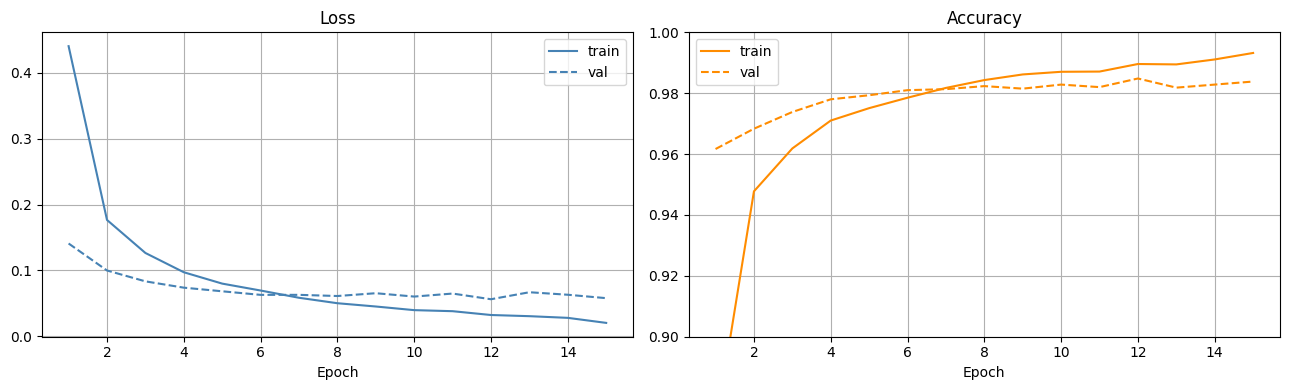

In [31]:
# Plot Keras training history
h = keras_history.history
epochs_ran = range(1, len(h['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs_ran, h['loss'],     label='train', color='steelblue')
axes[0].plot(epochs_ran, h['val_loss'], label='val',   color='steelblue', linestyle='--')
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_ran, h['accuracy'],     label='train', color='darkorange')
axes[1].plot(epochs_ran, h['val_accuracy'], label='val',   color='darkorange', linestyle='--')
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0.9, 1.0)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Understanding Overfitting vs Underfitting

The training/validation curves above reveal the model's learning dynamics:

| Situation | Training loss | Validation loss | Action |
|-----------|--------------|-----------------|--------|
| **Underfitting** | High | High | Increase model capacity, train longer |
| **Good fit** | Low | Low & similar | Done! |
| **Overfitting** | Low | Diverging upward | Add dropout, L2 regularization, more data |

Looking at the curves above: if train loss and validation loss **overlap closely**, the model is in the **good fit** zone — it generalises well and there is no sign of overfitting.

The `Dropout` layers we added are a **precautionary regularisation** technique. On MNIST this network rarely overfits because the dataset is large (54 000 training samples) relative to the model's capacity, so the curves naturally stay close together. Dropout becomes visibly important when:
- The training set is small relative to the number of parameters
- The model is very deep or wide
- You run for many more epochs

If you did see the validation loss diverging upward while training loss kept falling, Dropout (and techniques like L2 weight regularisation) would close that gap by preventing individual neurons from becoming overly specialised.

---
<a name='8'></a>
## 8. Saving and Loading a Model

After training a model you'll want to save it so you can:
- Use it later without retraining
- Deploy it to a server or mobile device
- Share it with others

In [32]:
# ── Option 1: Save in Keras native format (.keras) ────────────────
# Saves architecture + weights + optimizer state
model.save("mnist_model.keras")
print("Model saved as mnist_model.keras")

# Load it back
loaded_model = tf.keras.models.load_model("mnist_model.keras")
loss, acc = loaded_model.evaluate(X_test, Y_test, verbose=0)
print(f"Loaded model test accuracy: {acc:.4f}  (should match: {test_acc:.4f})")

Model saved as mnist_model.keras
Loaded model test accuracy: 0.9824  (should match: 0.9824)


In [33]:
# ── Option 2: Save only weights ───────────────────────────────────
# Useful when you want to keep a checkpoint during training
model.save_weights("mnist_weights.weights.h5")
print("Weights saved.")

# Restore weights into the same architecture
model.load_weights("mnist_weights.weights.h5")
print("Weights restored.")

Weights saved.
Weights restored.


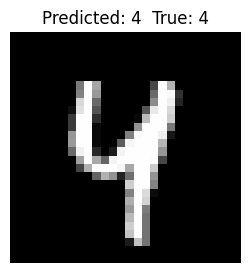

Class probabilities:
  Digit 0: 0.000  
  Digit 1: 0.000  
  Digit 2: 0.000  
  Digit 3: 0.000  
  Digit 4: 1.000  █████████████████████████████
  Digit 5: 0.000  
  Digit 6: 0.000  
  Digit 7: 0.000  
  Digit 8: 0.000  
  Digit 9: 0.000  


In [34]:
# ── Making predictions with a loaded model ────────────────────────
sample = X_test[42:43]             # shape (1, 784)
probs  = loaded_model.predict(sample, verbose=0)
predicted_digit = np.argmax(probs)
true_digit      = y_test_raw[42]

plt.figure(figsize=(3, 3))
plt.imshow(X_test_raw[42], cmap='gray')
plt.title(f"Predicted: {predicted_digit}  True: {true_digit}")
plt.axis('off')
plt.show()

print("Class probabilities:")
for i, p in enumerate(probs[0]):
    bar = '█' * int(p * 30)
    print(f"  Digit {i}: {p:.3f}  {bar}")

---
<a name='9'></a>
## 9. Common Mistakes and Tips

### Shape Errors

The most common error in TensorFlow is a **shape mismatch**. Always verify tensor shapes with `.shape` before and after operations.

```python
# When confused, print shapes at each step:
print("X:", X.shape)       # (batch, 784)
print("W1:", W1.shape)     # (784, 256)
print("X @ W1:", (X @ W1).shape)  # (batch, 256) ✓
```

### Forgetting to Cast dtypes

TensorFlow is strict about data types. If you mix `float32` and `float64`, you get an error:

```python
x = tf.constant([1.0, 2.0])           # float32 by default
y = tf.constant([1.0, 2.0], dtype=tf.float64)
x + y   # ← Error! Cast first:
x + tf.cast(y, tf.float32)  # ✓
```

### GradientTape Only Records During the `with` Block

```python
# WRONG — forward pass is outside the tape context
y = W * x + b
with tf.GradientTape() as tape:
    loss = (y - y_true)**2
grads = tape.gradient(loss, [W, b])  # returns None!

# CORRECT — entire forward + loss inside the tape
with tf.GradientTape() as tape:
    y    = W * x + b
    loss = (y - y_true)**2
grads = tape.gradient(loss, [W, b])  # ✓
```

### Gradient Tape Exhausts After `.gradient()`

By default, the tape is deleted after one call to `.gradient()`. If you need gradients twice:

```python
with tf.GradientTape(persistent=True) as tape:
    y = f(x)
dy_dw = tape.gradient(y, W)   # ✓
dy_db = tape.gradient(y, b)   # ✓ (works because persistent=True)
del tape                       # release manually when done
```

### `@tf.function` — Compiling for Speed

Decorating a function with `@tf.function` compiles it into a static graph the first time it is called, making subsequent calls much faster (especially on GPU):

```python
@tf.function
def train_step(X_batch, Y_batch):
    with tf.GradientTape() as tape:
        Y_pred = model(X_batch, training=True)
        loss   = loss_fn(Y_batch, Y_pred)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss
```

### Quick Reference: Keras Layer Cheat Sheet

| Layer | Usage | When to use |
|-------|-------|-------------|
| `Dense(n, activation='relu')` | Fully-connected layer | Standard hidden layer |
| `Dense(n, activation='softmax')` | Fully-connected output | Multi-class output |
| `Dense(1, activation='sigmoid')` | Binary output | Binary classification |
| `Dropout(rate)` | Random zeroing | Regularization |
| `BatchNormalization()` | Normalize activations | Deep networks |
| `Conv2D(filters, kernel_size)` | Convolution | Image inputs |
| `MaxPooling2D(pool_size)` | Spatial downsampling | After Conv2D |
| `Flatten()` | Reshape to 1D | Before first Dense |
| `LSTM(units)` | Recurrent layer | Sequence inputs |

In [ ]:
# ── Final summary: the full pipeline in one view ──────────────────
print("""
┌─────────────────────────────────────────────────────┐
│              TensorFlow Training Pipeline           │
├─────────────────────────────────────────────────────┤
│  1. Load & preprocess data                          │
│     • normalize, reshape, one-hot encode            │
│     • create tf.data.Dataset with .batch()          │
│                                                     │
│  2. Define model                                    │
│     • tf.keras.Sequential or custom tf.Variables    │
│                                                     │
│  3. Compile                                         │
│     • optimizer (Adam), loss (CrossEntropy)         │
│                                                     │
│  4. Train (for each epoch, for each batch):         │
│     a. Forward pass inside GradientTape             │
│     b. Compute loss                                 │
│     c. tape.gradient(loss, params)                  │
│     d. optimizer.apply_gradients(grads, params)     │
│                                                     │
│  5. Evaluate on held-out test set                   │
│                                                     │
│  6. Save model for later use                        │
└─────────────────────────────────────────────────────┘
""")

---
<a name='10'></a>
## 10. Keras Model Types and Layer Reference


Keras offers three ways to build a model, each suited to different levels of complexity.

---

#### 1. `Sequential` — Linear stack of layers
The simplest option. Layers are added one after another; each layer has exactly one input and one output.

```python
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10,  activation='softmax'),
])
```

**Use when:** the network is a straight pipeline with no branches, no shared layers, and no multiple inputs/outputs.

**Cannot handle:** skip connections, multiple inputs, multiple outputs, shared weights.

---

#### 2. Functional API — Explicit dataflow graph
You define tensors explicitly and wire them together. This lets you build any directed acyclic graph (DAG) of layers.

```python
inputs  = tf.keras.Input(shape=(784,))
x       = tf.keras.layers.Dense(256, activation='relu')(inputs)
x       = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(10, activation='softmax')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)
```

**Use when:** you need skip/residual connections (ResNet), multiple inputs (e.g. image + metadata), multiple outputs (e.g. classification + bounding box), or shared layer weights.

---

#### 3. Model Subclassing — Full Python control
You subclass `tf.keras.Model` and define the forward pass in `call()`. This is the most flexible option and mirrors PyTorch-style code.

```python
class MyNet(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.dense1 = tf.keras.layers.Dense(256, activation='relu')
        self.drop   = tf.keras.layers.Dropout(0.2)
        self.dense2 = tf.keras.layers.Dense(10,  activation='softmax')

    def call(self, x, training=False):
        x = self.dense1(x)
        x = self.drop(x, training=training)  # training flag controls dropout
        return self.dense2(x)

model = MyNet()
```

**Use when:** the forward pass has dynamic control flow (loops, conditionals), research models, or anything that doesn't fit neatly into a static graph.

---

#### Comparison

| | Sequential | Functional API | Subclassing |
|---|---|---|---|
| Complexity | Low | Medium | High |
| Skip connections | No | **Yes** | **Yes** |
| Multiple inputs/outputs | No | **Yes** | **Yes** |
| Dynamic control flow | No | No | **Yes** |
| `.summary()` / plotting | Full support | Full support | Limited |
| Recommended for | Beginners, simple nets | Most real models | Research / custom logic |

---

### Keras Layer Types

Beyond `Dense`, Keras has layers for every major network architecture.

---

#### Core layers

| Layer | Key args | What it does |
|---|---|---|
| `Dense(units, activation)` | `units`, `activation` | Fully-connected; every input connected to every neuron |
| `Flatten()` | — | Reshapes any nD tensor to 1D (e.g. `(batch,28,28)` → `(batch,784)`) |
| `Reshape(target_shape)` | `target_shape` | Reshape to an arbitrary shape |
| `Lambda(fn)` | `fn` | Wrap any arbitrary Python/TF function as a layer |

---

#### Regularisation layers

| Layer | Key args | What it does |
|---|---|---|
| `Dropout(rate)` | `rate` (0–1) | Randomly zero out neurons during training to prevent co-adaptation |
| `BatchNormalization()` | — | Normalises activations to zero mean / unit variance per batch; speeds up training in deep networks |
| `LayerNormalization()` | — | Like BatchNorm but normalises across features (standard in Transformers) |
| `GaussianNoise(stddev)` | `stddev` | Adds random noise during training; acts as a data augmentation form of regularisation |

---

#### Convolutional layers — for image / spatial data

| Layer | Key args | What it does |
|---|---|---|
| `Conv2D(filters, kernel_size, activation)` | `filters`, `kernel_size`, `strides`, `padding` | Slides a small filter over a 2D spatial input; each filter learns to detect a local pattern (edge, texture…) |
| `SeparableConv2D(...)` | same as Conv2D | Depthwise + pointwise convolution; same expressiveness as Conv2D but far fewer parameters |
| `Conv2DTranspose(...)` | same as Conv2D | "Reverse" convolution; used in decoders and image generation to upsample |
| `MaxPooling2D(pool_size)` | `pool_size`, `strides` | Takes the max in each window; reduces spatial size and adds translation invariance |
| `GlobalAveragePooling2D()` | — | Averages across the entire spatial map to a single number per filter; replaces `Flatten` before the final `Dense` in modern CNNs |

> **Shape intuition for Conv2D:**
> Input `(batch, H, W, C_in)` → output `(batch, H', W', filters)`.
> With `padding='same'` the spatial size is preserved; with `padding='valid'` it shrinks.

---

#### Recurrent layers — for sequence / time-series data

| Layer | Key args | What it does |
|---|---|---|
| `LSTM(units)` | `units`, `return_sequences` | Long Short-Term Memory; maintains a cell state to capture long-range dependencies |
| `GRU(units)` | `units`, `return_sequences` | Gated Recurrent Unit; simpler and faster than LSTM, often comparable in quality |
| `SimpleRNN(units)` | `units` | Basic recurrent layer; suffers from vanishing gradients, rarely used in practice |
| `Bidirectional(layer)` | any RNN layer | Wraps an RNN so it reads the sequence both forward and backward; doubles the output size |

> `return_sequences=True` passes the hidden state at **every** timestep to the next layer (needed when stacking RNNs).
> `return_sequences=False` (default) passes only the **last** timestep's state (needed before a `Dense` output layer).

---

#### Embedding layer — for text / categorical data

| Layer | Key args | What it does |
|---|---|---|
| `Embedding(vocab_size, embed_dim)` | `input_length` | Learns a dense vector for each integer token; the standard first layer in NLP models |

---

#### Attention / Transformer layers

| Layer | What it does |
|---|---|
| `MultiHeadAttention(num_heads, key_dim)` | Scaled dot-product attention across multiple representation subspaces; the core of Transformer models |
| `LayerNormalization()` | Normalises features; used after every sub-layer in a Transformer block |

---

#### Merging layers — used in the Functional API to combine branches

| Layer | What it does |
|---|---|
| `Add()` | Element-wise addition of two tensors — the skip/residual connection in ResNets |
| `Concatenate(axis)` | Stacks tensors along an axis — the skip connection in U-Net |
| `Multiply()` | Element-wise multiplication — used in attention gates |
| `Average()` | Element-wise average — model ensembling within a graph |

In [35]:
# ── Functional API example ───────────────────────────────────────
# Same 784→256→128→10 architecture, but written with explicit tensor wiring.
# This style is required as soon as you need skip connections or multiple I/O.

inputs  = tf.keras.Input(shape=(784,), name="pixels")
x       = tf.keras.layers.Dense(256, activation="relu")(inputs)
x       = tf.keras.layers.Dropout(0.2)(x)
x       = tf.keras.layers.Dense(128, activation="relu")(x)
x       = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(10, activation="softmax", name="probs")(x)

functional_model = tf.keras.Model(inputs=inputs, outputs=outputs,
                                  name="mnist_functional")
functional_model.summary()


# ── Subclassed model example ─────────────────────────────────────
# Full Python control over the forward pass.
# Note: training=False argument is important — it switches Dropout off at inference.

class MnistNet(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.dense1 = tf.keras.layers.Dense(256, activation="relu")
        self.drop1  = tf.keras.layers.Dropout(0.2)
        self.dense2 = tf.keras.layers.Dense(128, activation="relu")
        self.drop2  = tf.keras.layers.Dropout(0.2)
        self.out    = tf.keras.layers.Dense(10,  activation="softmax")

    def call(self, x, training=False):
        x = self.dense1(x)
        x = self.drop1(x, training=training)
        x = self.dense2(x)
        x = self.drop2(x, training=training)
        return self.out(x)

subclassed_model = MnistNet()
# Build by passing a dummy batch (needed before .summary())
subclassed_model(tf.zeros((1, 784)))
subclassed_model.summary()


# ── All three model types produce identical results ───────────────
functional_model.compile(optimizer="adam",
                         loss="categorical_crossentropy",
                         metrics=["accuracy"])
_, acc = functional_model.evaluate(X_test, Y_test, verbose=0)
print(f"Functional model test accuracy (untrained): {acc:.4f}")

Model: "mnist_functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pixels (InputLayer)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ probs (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (1, 256)               │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (1, 128)               │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (1, 10)                │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Functional model test accuracy (untrained): 0.0740
